In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "IPAexGothic"
plt.rcParams["axes.unicode_minus"] = False

%precision 3
%matplotlib inline

In [2]:
x_set = np.array([1, 2, 3, 4, 5, 6])

In [3]:
def f(x):
    if x in x_set:
        return x / 21
    else:
        return 0


In [4]:
X = [x_set, f]

In [5]:
prob = np.array([f(x_k) for x_k in x_set])
dict(zip(x_set, prob))


{np.int64(1): 0.048,
 np.int64(2): 0.095,
 np.int64(3): 0.143,
 np.int64(4): 0.190,
 np.int64(5): 0.238,
 np.int64(6): 0.286}

In [6]:
np.all(prob > 0)

np.True_

In [7]:
np.sum(prob)

1.000

In [8]:
def F(x):
    return np.sum([f(x_k) for x_k in x_set if x_k <= x])

In [9]:
F(3)

0.286

In [10]:
y_set = np.array([2 * x_K + 3 for x_K in x_set])
prob = np.array([f(x_k) for x_k in x_set])
dict(zip(y_set, prob))

{np.int64(5): 0.048,
 np.int64(7): 0.095,
 np.int64(9): 0.143,
 np.int64(11): 0.190,
 np.int64(13): 0.238,
 np.int64(15): 0.286}

In [11]:
np.sum([x_k * f(x_k) for x_k in x_set])

4.333

In [12]:
sample = np.random.choice(x_set, int(1e6), p=prob)
np.mean(sample)

4.331

In [13]:
def E(x, g=lambda x: x):
    x_set, f = X
    return np.sum([g(x_k) * f(x_k) for x_k in x_set])

In [14]:
E(X)

4.333

In [15]:
E(X, g = lambda x: 2 * x + 3)

11.667

In [16]:
2 * E(X) + 3

11.667

In [17]:
mean = E(X)
np.sum([(x_k - mean) ** 2 * f(x_k) for x_k in x_set])

2.222

In [18]:
def V(X, g = lambda x: x):
    x_set, f = X
    mean = E(X, g)
    return np.sum([(g(x_k) - mean) ** 2 * f(x_k) for x_k in x_set])

In [19]:
V(X)

2.222

In [20]:
V(X, lambda x: 2 * x + 3)

8.889

In [21]:
2 ** 2 * V(X)

8.889

In [22]:
x_set = np.arange(2, 13)
y_set = np.arange(1, 7)

In [23]:
def f_XY(x, y):
    if 1 <= y and 1 <= x - y <= 6:
        return y * (x - y) / 441
    else:
        return 0

In [24]:
XY = [x_set, y_set, f_XY]

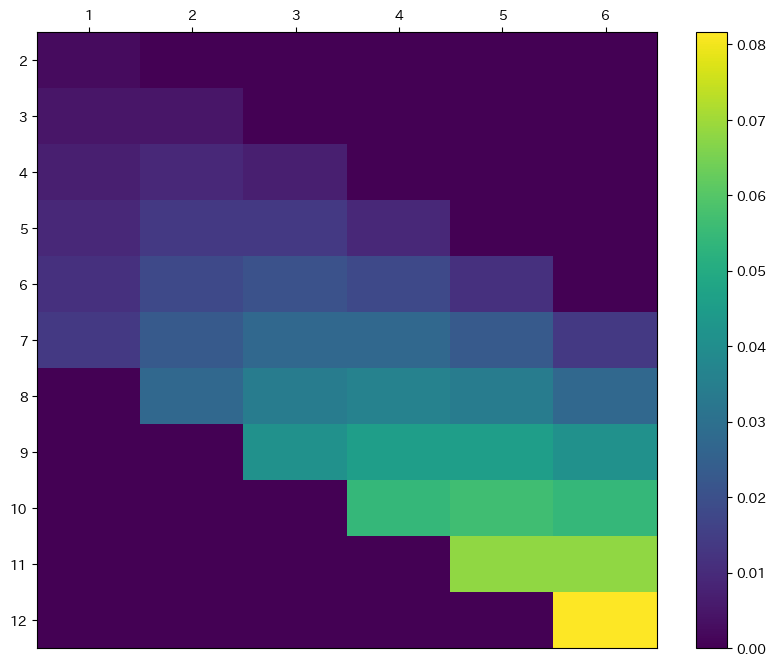

In [25]:
prob = np.array([[f_XY(x_i, y_j) for y_j in y_set] for x_i in x_set])
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

c = ax.pcolor(prob)
ax.set_xticks(np.arange(prob.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(prob.shape[0]) + 0.5, minor=False)
ax.set_xticklabels(np.arange(1, 7), minor=False)
ax.set_yticklabels(np.arange(2, 13), minor=False)

ax.invert_yaxis()
ax.xaxis.tick_top()
fig.colorbar(c, ax=ax)
plt.show()

In [26]:
np.all(prob >= 0)

np.True_

In [27]:
np.sum(prob)

1.000

In [28]:
def f_X(x):
    return np.sum([f_XY(x, y_k) for y_k in y_set])

In [29]:
def f_Y(y):
    return np.sum([f_XY(x_k, y) for x_k in x_set])

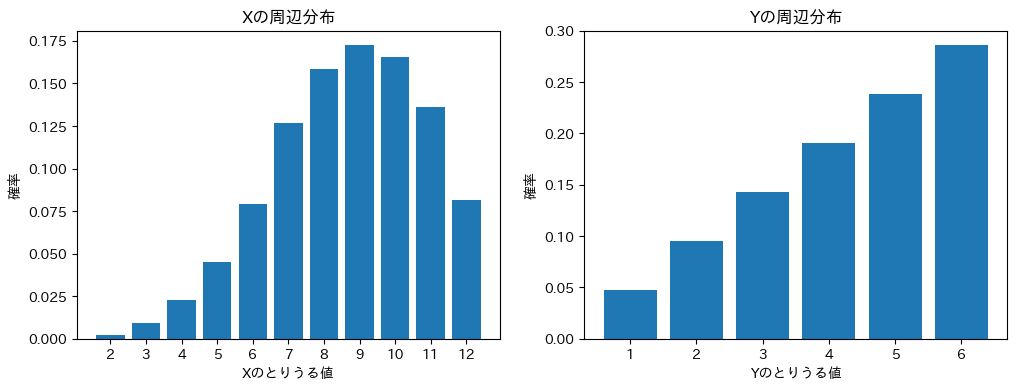

In [30]:
prob_x = np.array([f_X(x_k) for x_k in x_set])
prob_y = np.array([f_Y(y_k) for y_k in y_set])

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.bar(x_set, prob_x)
ax1.set_title('Xの周辺分布')
ax1.set_xlabel('Xのとりうる値')
ax1.set_ylabel('確率')
ax1.set_xticks(x_set)

ax2.bar(y_set, prob_y)
ax2.set_title('Yの周辺分布')
ax2.set_xlabel('Yのとりうる値')
ax2.set_ylabel('確率')
ax2.set_xticks(y_set)

plt.show()



In [31]:
np.sum([x_i * f_XY(x_i, y_j) for x_i in x_set for y_j in y_set])

8.667

In [32]:
def E(XY, g):
    x_set, y_set, f_XY = XY
    return np.sum([g(x_i, y_j) * f_XY(x_i, y_j) for x_i in x_set for y_j in y_set])

In [33]:
mean_X = E(XY, lambda x, y: x)
mean_X

8.667

In [34]:
mean_Y = E(XY, lambda x, y: y)
mean_Y

4.333

In [35]:
a, b = 2, 3

In [36]:
E(XY, lambda x, y: a * x + b * y)

30.333

In [37]:
np.sum([(x_i - mean_X) ** 2 * f_XY(x_i, y_j) for x_i in x_set for y_j in y_set])

4.444

In [38]:
def V(XY, g):
    x_set, y_set, f_XY = XY
    mean = E(XY, g)
    return np.sum([(g(x_i, y_j) - mean) ** 2 * f_XY(x_i, y_j) for x_i in x_set for y_j in y_set])

In [39]:
var_X = V(XY, lambda x, y: x)
var_X

4.444

In [40]:
vay_Y = V(XY, lambda x, y: y)
vay_Y

2.222

In [41]:
def Cov(XY):
    x_set, y_set, f_XY = XY
    mean_X = E(XY, lambda x, y: x)
    mean_Y = E(XY, lambda x, y: y)
    return np.sum([(x_i - mean_X) * (y_j - mean_Y) * f_XY(x_i, y_j) for x_i in x_set for y_j in y_set]) 

In [42]:
cov_xy = Cov(XY)
cov_xy

2.222

In [43]:
V(XY, lambda x, y: a * x + b * y)

64.444

In [44]:
a ** 2 * var_X + b ** 2 * vay_Y + 2 * a * b * cov_xy

64.444

In [45]:
cov_xy / np.sqrt(var_X * vay_Y)



0.707